# OVERVIEW
This notebook acts as an example of how to use the code set out in src files.

## *IMPORTS*

Script created in trading_bot project when encountering import issues due to notebook files and working in a different directory. same script added across every project. Also changed the names of plotting files to match the project name, as python automatically was chosing the first option when called. 

In [20]:
import sys
from pathlib import Path
if not globals().get("_TRADING_PORTFOLIO_PATHS_READY"):
    _HERE = (
        Path(__file__).resolve().parent
        if "__file__" in globals()
        else Path.cwd().resolve()
    )
    _PROJECTS = (
        "past_market_analysis",
        "technical_analysis",
        "options_pricing",
        "time_series_forecasting",
        "portfolio_construction",
        "ml_fundamentals",
        "ml_trading_signals",
        "risk_management",
        "trading_bot",
    )
    _REPO_ROOT = next(
        (
            directory
            for directory in (_HERE, *_HERE.parents)
            if all((directory / project).is_dir() for project in _PROJECTS)
        ),
        None,
    )
    if _REPO_ROOT is None:
        raise RuntimeError(
            "Could not locate the trading_portfolio repository root."
        )
    _SRC_PATHS = [
        str((_REPO_ROOT / project / "src").resolve())
        for project in _PROJECTS
    ]
    sys.path.extend(path for path in _SRC_PATHS if path not in sys.path)
    _TRADING_PORTFOLIO_PATHS_READY = True


In [21]:
#importing libraries and functions defined in other files

import sys


import matplotlib as plt
import pandas as pd

from data_loader import fetch_price_data  #from past_market_analysis project

from indicators import add_all_indicators
from signals import backtest_signals, robust_composite_signal
from plotting_technical_analysis import plot_backtest, plot_signals


## **Analysis**

We showcase our code using the S&P 500

In [22]:
ticker = "SPY" 
df = fetch_price_data(ticker, period="2y", interval="1d")

#now have imported the price data, we apply all of our functions to the dataframe
df = add_all_indicators(df)
df = robust_composite_signal(df)
df = backtest_signals(df)

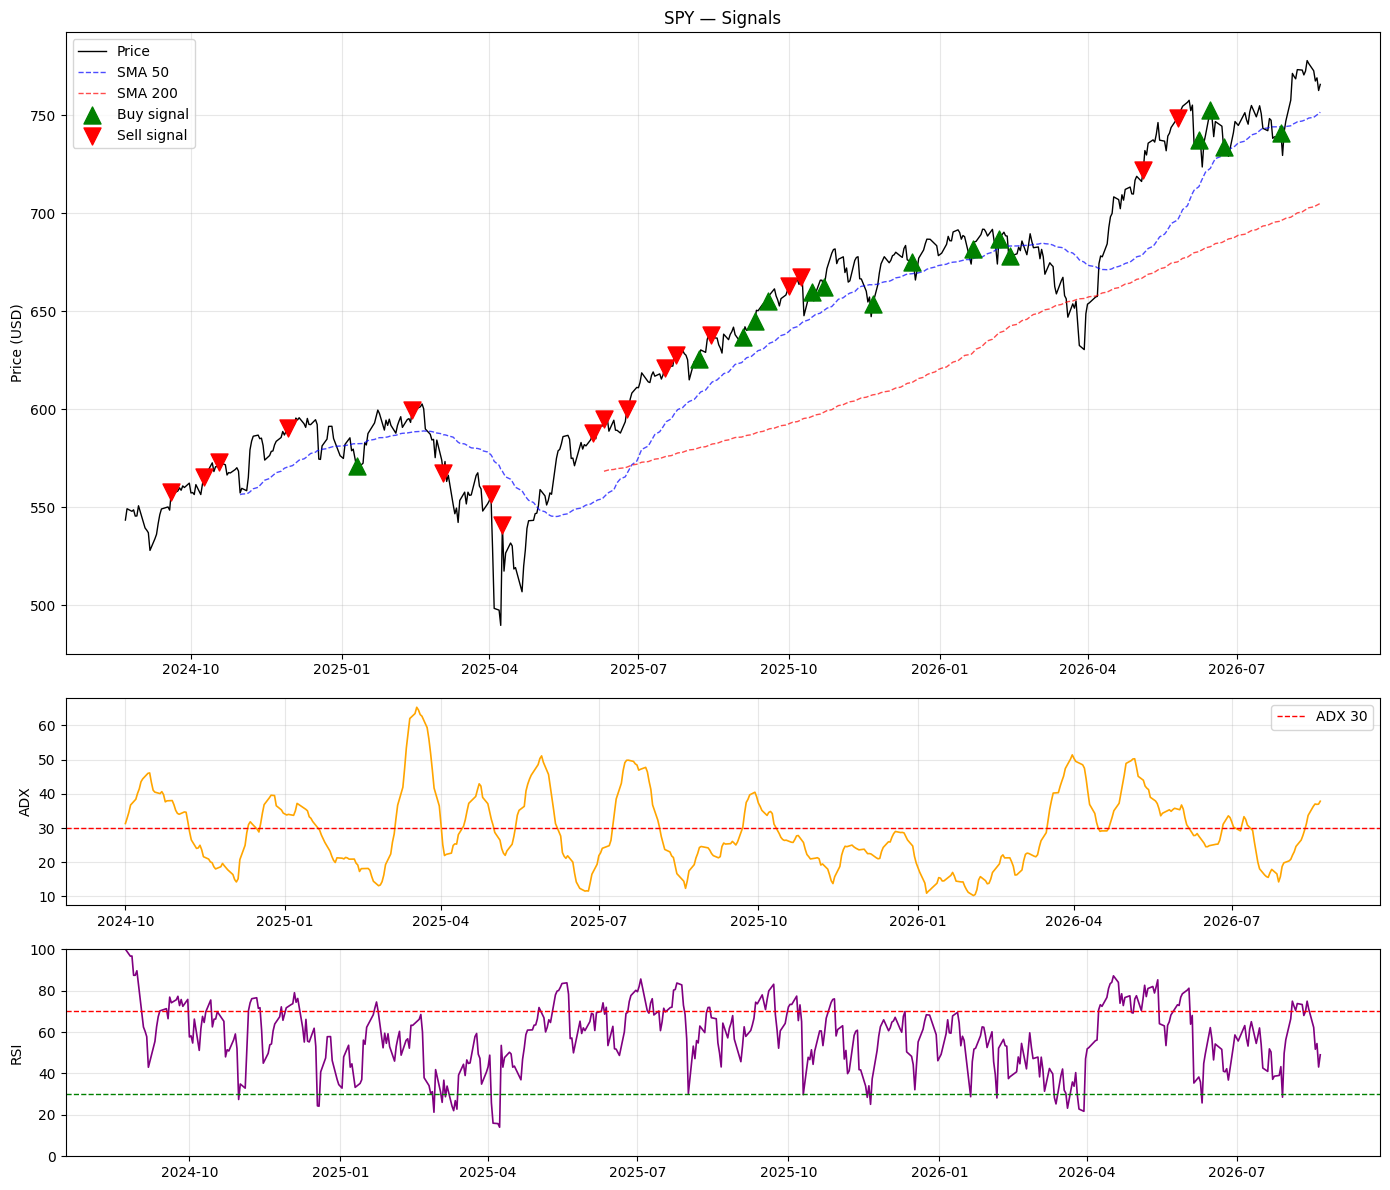

In [23]:
#now look to visualise what these functions have done, first with the places we 'should've' bought and sold according to our model
plot_signals(df, ticker)

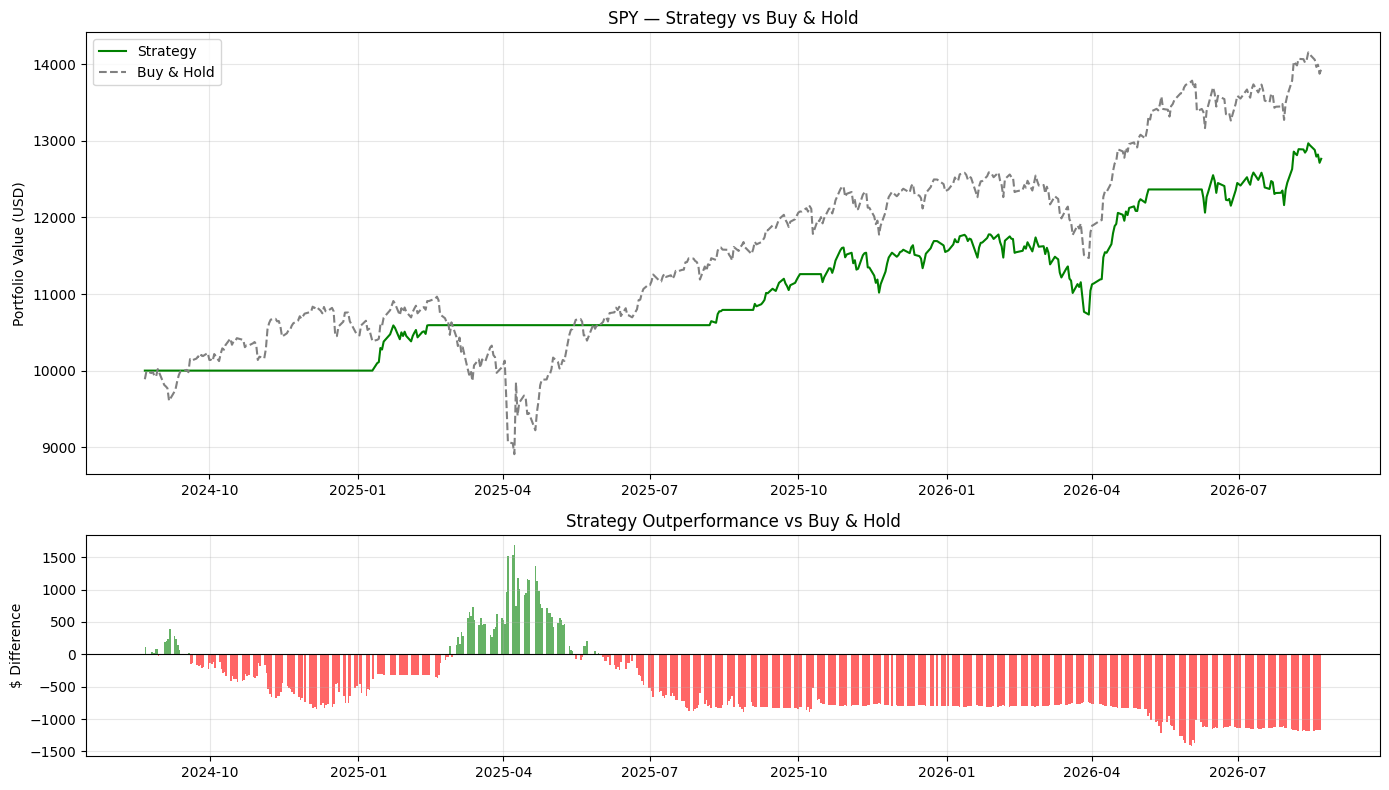

In [24]:
#now the profit/loss of doing that method, compared to just buying and holding
plot_backtest(df, ticker)

In [25]:
#now for some numerical values of whats happening above

final_strategy = df['Portfolio_Value'].iloc[-1]
final_buyhold  = df['Buy_Hold_Value'].iloc[-1]

print(f"{ticker} — Strategy vs Buy & Hold")
print(f"Strategy return:   {(final_strategy/10000 - 1)*100:.2f}%")
print(f"Buy & Hold return: {(final_buyhold/10000 - 1)*100:.2f}%")

SPY — Strategy vs Buy & Hold
Strategy return:   27.66%
Buy & Hold return: 39.34%


We now look to see about the differences between the accuracy of our model between different tickers. 

In [26]:
tickers = ["SPY", "JNJ", "SOL-USD", "TSLA"]
results = []

for tkr in tickers:
    d = fetch_price_data(tkr, period="2y", interval="1d")
    d = add_all_indicators(d)
    d = robust_composite_signal(d)
    d = backtest_signals(d)
    
    strat_ret = (d['Portfolio_Value'].iloc[-1] / 10000 - 1) * 100
    bh_ret    = (d['Buy_Hold_Value'].iloc[-1] / 10000 - 1) * 100
    
    results.append({
        'Ticker': tkr,
        'Strategy_Return_%': round(strat_ret, 2),
        'BuyHold_Return_%':  round(bh_ret, 2),
        'Outperformance_%':  round(strat_ret - bh_ret, 2)
    })

summary = pd.DataFrame(results).set_index('Ticker')
summary

,Strategy_Return_%,BuyHold_Return_%,Outperformance_%
Ticker,,,
SPY,27.66,39.34,-11.68
JNJ,80.76,76.55,4.20
SOL-USD,-26.94,-34.57,7.62
TSLA,2.34,62.12,-59.78


We see here that the outperformance varies massively based upon the tickers involved. One key reason for this is that the system does not buy when the period is started, but rather waits for a buy signal. In the case of the S&P 500, approximately half of the difference between the 2 strategies occurs in the first 6 months where no buy takes place, as the system is waiting for the first buy signal. The system is designed to detect sharp turns in the market, which we see for SOL (cryptocurrency) it does noticeably better than just holding.